# Module 2: Content-Based Recommendation Systems
This notebook walk through an example of Content-Based Recommendation Systems from the Spotify dataset.

## Data collection 

Based on the MMDS readings and discussion in class, I wondered if using different song features (e.g., title, lyrics, tempo) would result in different embeddings, and as a result, different recommendations. 

The dataset used here is retrieved from https://www.kaggle.com/datasets/bwandowando/spotify-songs-with-attributes-and-lyrics.
The author collected the data by querying the Spotify API and combining multiple sources together. 
Data columns are described in `data/dataset_description.md`


In [ ]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_PATH        = "../data/spotify/songs_with_attributes_and_lyrics.csv"
SAMPLE_DATA_PATH = "../data/spotify/spotify_sample.parquet"
N_SAMPLE       = 25_000
COL_TRACK_ID   = "id"
COL_TRACK_NAME = "name"
COL_ARTIST     = "artists"
COL_LYRICS     = "lyrics"
AUDIO_COLS     = [
    "danceability", "energy", "loudness", "speechiness",
    "acousticness", "instrumentalness", "liveness", "valence", "tempo",
]

## 0. Load data

In [ ]:
## LOAD SAMPLED DATASET IF AVAILABLE 

if os.path.exists(SAMPLE_DATA_PATH):
    df = pd.read_parquet(SAMPLE_DATA_PATH)
    print(f"Loaded sample from {SAMPLE_DATA_PATH}: {len(df):,} songs, {df[COL_ARTIST].nunique():,} artists")
else:
    print("No sampled dataset found. Sample from original dataset")

    KEY_NOTE_MAP = {
        "C": 0, "C#": 1, "Db": 1, "D": 2, "D#": 3, "Eb": 3,
        "E": 4, "F": 5, "F#": 6, "Gb": 6, "G": 7,
        "G#": 8, "Ab": 8, "A": 9, "A#": 10, "Bb": 10, "B": 11,
    }
    def parse_key(v):
        try: return int(float(v))
        except: return KEY_NOTE_MAP.get(str(v).strip(), -1)
    def parse_mode(v):
        s = str(v).strip().lower()
        if s in ("major", "maj"): return 1
        if s in ("minor", "min"): return 0
        try: return int(float(s))
        except: return -1

    df_raw = pd.read_csv(DATA_PATH, low_memory=False)
    df_raw["key_clean"]  = df_raw["key"].apply(parse_key)
    df_raw["mode_clean"] = df_raw["mode"].apply(parse_mode)
    df_raw["wc"] = df_raw[COL_LYRICS].apply(lambda x: len(str(x).split()) if pd.notna(x) else 0)
    eligible = df_raw[
        (df_raw["wc"] >= 50)
        & df_raw[AUDIO_COLS].notna().all(axis=1)
        & df_raw["key_clean"].between(0, 11)
        & df_raw["mode_clean"].isin([0, 1])
    ].reset_index(drop=True)

    df = eligible.sample(n=min(N_SAMPLE, len(eligible)), random_state=RANDOM_STATE).reset_index(drop=True)
    print(f"Working sample: {len(df):,} songs, {df[COL_ARTIST].nunique():,} artists")

    # Save for future use
    df.to_parquet(SAMPLE_DATA_PATH)

---
## 1. Two Basic Architectures

> *"There are two basic architectures for a recommendation system:*
> *Content-based systems examine properties of the items recommended. For instance, if a Netflix user*
> *has watched many cowboy movies, then recommend a movie classified in the database as having the 'cowboy' genre.*
> *Collaborative filtering systems recommend items based on similarity measures between users and/or items.*
> *The items recommended to a user are those preferred by similar users."*


| | Content-Based | Collaborative Filtering |
|---|---|---|
| **Signal** | Item properties (lyrics, audio, genre) | User behavior (plays, skips, likes) |
| **Cold start** | ✅ Works for new items | ❌ Needs history |
| **Discovery** | ❌ Stays in comfort zone | ✅ Can surprise |
| **Interpretable** | ✅ "Similar lyrics/tempo" | ❌ Black-box latent factors |

**In this notebook:** we focus entirely on the content-based approach.

---
## 2. Motivating Example: How Does Spotify Know Your Vibe?

> *"Out of many songs being published each day, how do we know which to recommend?*
> *If Spotify recommends a track because it 'feels like your vibe,' that usually comes from a combination:*
> *1. Collaborative filtering ('people like you also liked…')*
> *2. Content-based/audio analysis (tempo, timbre, danceability, mood)*
> *3. Natural language/context models (what the internet and playlists say about artists/tracks)*
> *4. Contextual personalization (time of day, workout mode, commuting, etc.)"*


The embedding Spotify builds captures:
- **Playlist co-occurrence:** songs that appear together in many playlists
- **Fan overlap:** artists whose audiences listen to the same other artists
- **Online subcultures:** editorial curation, music journalism, social discussion
- **Music discovery flows:** what users tend to play after a given song

> *"'Vibes' are not purely acoustic. They're mostly latent taste relationships learned from huge-scale behavior data,*
> *enriched with content understanding."*


**Today's simplification:** we use only content signals (audio features + lyrics). No user data.

---
## 3. Item Profiles

> *"In a content-based system, we must construct for each item a profile, which is a record or collection*
> *of records representing important characteristics of that item. In simple cases, the profile consists of*
> *some characteristics of the item that are easily discovered."*


For movies, relevant features might be: actors, director, year, genre.

**Class exercise:** For songs, what could be some relevant features?

*(Think before revealing the next cell.)*

In [2]:
# Reveal: one complete song profile from our dataset
example = df.sample(1, random_state=7).iloc[0]
print(f"Song   : {example[COL_TRACK_NAME]}")
print(f"Artist : {example[COL_ARTIST]}")
print(f"")
print("── Audio Features ──────────────────────────────────")
for col in AUDIO_COLS:
    print(f"  {col:<20}: {example[col]:.4f}")
print(f"  {'key':<20}: {example['key_clean']}  (0=C, 1=C#, …, 11=B)")
print(f"  {'mode':<20}: {example['mode_clean']}  (0=minor, 1=major)")
print(f"")
print("── Lyrics (first 200 chars) ────────────────────────")
print(" ", str(example[COL_LYRICS])[:200], "…")

Song   : Death Of Me
Artist : From Ashes to New

── Audio Features ──────────────────────────────────
  danceability        : 0.4850
  energy              : 0.9700
  loudness            : -3.9920
  speechiness         : 0.0604
  acousticness        : 0.0001
  instrumentalness    : 0.0000
  liveness            : 0.1310
  valence             : 0.4530
  tempo               : 97.0490
  key                 : 2  (0=C, 1=C#, …, 11=B)
  mode                : 1  (0=minor, 1=major)

── Lyrics (first 200 chars) ────────────────────────
  Sometimes I hate myself like everybody else
 Can't tell who's fake and who's a friend
 So fill me with regret until there's nothing left
 'Cause everybody likes you when you're dead
 I'm going under
  …


---
## 4. Discovering Features of Items

> *"A song is consisted of lyrics and instrumental.*
> *We can use lyrics. We can also represent a song by a vector of its chords.*
> (Think of more examples.)"*


| Feature type | Examples | Representation |
|---|---|---|
| **Lyrics** | words, themes, emotion | TF-IDF, Word2Vec |
| **Audio** | tempo, energy, valence | continuous vector |
| **Structure** | key, mode, time signature | one-hot encoding |
| **Metadata** | artist, year, genre | one-hot / embedding |

---
## 5. Representing Item Profiles: One-Hot for Categorical Features

> *"Our ultimate goal for content-based recommendation is to create both an item profile consisting of*
> *feature-value pairs and a user profile summarizing the preferences of the user, based on their row of*
> *the utility matrix. We imagined a vector of 0's and 1's, where a 1 represented the occurrence of a*
> *high-TF-IDF word in the document."*


> *"It is easy to do so for features that are sets of discrete values. For example, if one feature of movies*
> *is the set of actors, then imagine that there is a component for each actor, with 1 if the actor is in the movie,*
> *and 0 if not. Likewise, we can have a component for each possible director, and each possible genre."*


For songs, the **key** (12 chromatic pitches) is categorical — C major and D major are not "1 apart" in any meaningful sense.
We one-hot encode it into 12 binary dimensions.

In [3]:
key_names = ["C", "C#", "D", "D#", "E", "F", "F#", "G", "G#", "A", "A#", "B"]

# Show raw key value vs one-hot encoding for 5 songs
sample5 = df.sample(5, random_state=42)

print("Raw representation (key as integer):")
print(sample5[[COL_TRACK_NAME, "key_clean", "mode_clean"]].to_string(index=False))
print()

# Build one-hot manually for illustration
print("One-hot encoding of key + mode:")
print(f"  {'Song':<35} | {'Key vector (C … B)':^30} | mode")
print("  " + "-" * 75)
for _, row in sample5.iterrows():
    key_vec = [0] * 12
    key_vec[int(row["key_clean"])] = 1
    mode_val = int(row["mode_clean"])
    print(f"  {row[COL_TRACK_NAME][:33]:<35} | {str(key_vec):^30} | {mode_val}  ({'major' if mode_val else 'minor'})")

Raw representation (key as integer):
                                  name  key_clean  mode_clean
                            Turpentine          9           1
                      Love Is Mystical          7           0
I Wish You Love - Live at The Symphony          0           1
                                O Siem          8           1
                             Speakeasy          0           1

One-hot encoding of key + mode:
  Song                                |       Key vector (C … B)       | mode
  ---------------------------------------------------------------------------
  Turpentine                          | [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0] | 1  (major)
  Love Is Mystical                    | [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0] | 0  (minor)
  I Wish You Love - Live at The Sym   | [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0] | 1  (major)
  O Siem                              | [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0] | 1  (major)
  Speakeasy                           | [1

In [4]:
# Build key+mode features for full sample
mlb_key = MultiLabelBinarizer(classes=list(range(12)))
key_onehot = mlb_key.fit_transform(df["key_clean"].apply(lambda k: [k]))
mode_col   = df["mode_clean"].values.reshape(-1, 1)
keymode_features = np.hstack([key_onehot, mode_col])

print(f"Key+Mode feature matrix shape: {keymode_features.shape}")
print(f"  → {keymode_features.shape[0]:,} songs × {keymode_features.shape[1]} dimensions (12 key + 1 mode)")

Key+Mode feature matrix shape: (25000, 13)
  → 25,000 songs × 13 dimensions (12 key + 1 mode)


---
## 6. Representing Item Profiles: Continuous Audio Features

> *"There is another class of features that is not readily represented by Boolean vectors: those features*
> *that are numerical. For instance, we might take the average rating for movies to be a feature, and this*
> *average is a real number. It does not make sense to have one component for each of the possible average ratings.*
> *Two ratings that are close but not identical should be considered more similar than widely differing ratings."*


Audio features like `tempo` (50–200 BPM) and `loudness` (−60–0 dB) are on very different scales.
**Standardization** (zero mean, unit variance) puts all features on equal footing before distance computation.

In [5]:
scaler = StandardScaler()
audio_features = scaler.fit_transform(df[AUDIO_COLS].fillna(df[AUDIO_COLS].median()))

# Compare two contrasting songs: high-energy EDM vs soft acoustic
edm_idx = df["energy"].idxmax()
acoustic_idx = df["acousticness"].idxmax()

edm_song = df.loc[edm_idx, COL_TRACK_NAME]
acoustic_song = df.loc[acoustic_idx, COL_TRACK_NAME]

print(f"Comparing raw vs standardized features:")
print(f"  Song 1 (high energy): {edm_song}")
print(f"  Song 2 (high acoustic): {acoustic_song}")
print()
print(f"  {'Feature':<20} {'Raw EDM':>10} {'Raw Acoustic':>14} {'Std EDM':>10} {'Std Acoustic':>14}")
print("  " + "-" * 72)
for i, col in enumerate(AUDIO_COLS):
    raw_edm  = df.loc[edm_idx, col]
    raw_ac   = df.loc[acoustic_idx, col]
    std_edm  = audio_features[edm_idx, i]
    std_ac   = audio_features[acoustic_idx, i]
    print(f"  {col:<20} {raw_edm:>10.3f} {raw_ac:>14.3f} {std_edm:>10.3f} {std_ac:>14.3f}")

Comparing raw vs standardized features:
  Song 1 (high energy): Datura Dream
  Song 2 (high acoustic): Gulf Coast Blues

  Feature                 Raw EDM   Raw Acoustic    Std EDM   Std Acoustic
  ------------------------------------------------------------------------
  danceability              0.358          0.601     -1.166          0.276
  energy                    1.000          0.080      1.456         -2.445
  loudness                 -3.489        -16.680      1.155         -2.396
  speechiness               0.331          0.042      2.595         -0.447
  acousticness              0.010          0.996     -0.865          2.342
  instrumentalness          0.038          0.088     -0.194          0.051
  liveness                  0.243          0.282      0.125          0.326
  valence                   0.141          0.251     -1.399         -0.961
  tempo                   167.101         93.374      1.534         -0.989


---
## 7. User Profiles

> *"We not only need to create vectors describing items; we need to create vectors with the same components*
> *that describe the user's preferences. We have the utility matrix representing the connection between users*
> *and items. Recall the nonblank matrix entries could be just 1's representing user purchases or a similar*
> *connection, or they could be arbitrary numbers representing a rating or degree of affection.*
> *With this information, the best estimate we can make regarding which items the user likes is some*
> *aggregation of the profiles of those items. If the utility matrix has only 1's, then the natural aggregate*
> *is the average of the components."*


**Concretely:** a user's taste vector = average of the audio feature vectors of all songs they liked.

In [6]:
# Simulate a user who liked 3 songs
liked_songs = df.sample(3, random_state=99)
liked_indices = liked_songs.index.tolist()

print("User's liked songs:")
for _, row in liked_songs.iterrows():
    print(f"  - {row[COL_TRACK_NAME]} by {row[COL_ARTIST]}")
    print(f"    energy={row['energy']:.2f}, valence={row['valence']:.2f}, tempo={row['tempo']:.1f}")
print()

# User profile = average of liked song vectors
user_profile = audio_features[liked_indices].mean(axis=0)

print("User profile vector (standardized audio features):")
print(f"  {'Feature':<20} {'Profile value':>14}  {'Interpretation'}")
print("  " + "-" * 60)
for i, col in enumerate(AUDIO_COLS):
    val = user_profile[i]
    interp = "above average" if val > 0.3 else ("below average" if val < -0.3 else "average")
    print(f"  {col:<20} {val:>14.3f}  {interp}")

User's liked songs:
  - 1979 - Remastered 2012 by The Smashing Pumpkins
    energy=0.79, valence=0.96, tempo=126.9
  - Pack Up The Louie by Caro Emerald
    energy=0.65, valence=0.96, tempo=196.0
  - 500 by Arvid Lundquist
    energy=0.75, valence=0.50, tempo=167.9

User profile vector (standardized audio features):
  Feature               Profile value  Interpretation
  ------------------------------------------------------------
  danceability                  1.265  above average
  energy                        0.305  above average
  loudness                      0.236  average
  speechiness                   0.763  above average
  acousticness                 -0.307  below average
  instrumentalness              0.579  above average
  liveness                      0.215  average
  valence                       1.260  above average
  tempo                         1.414  above average


---
## 8. Recommending Items to Users

> *"With profile vectors for both users and items, we can estimate the degree to which a user would prefer*
> *an item by computing the cosine distance between the user's and item's vectors."*


> *"The random-hyperplane and locality-sensitive-hashing techniques can be used to place (just) item profiles*
> *in buckets. In that way, given a user to whom we want to recommend some items, we can apply the same*
> *two techniques — random hyperplanes and LSH — to determine in which buckets we must look for items*
> *that might have a small cosine distance from the user. — For this lecture, just understand that LSH makes*
> *similar users or items easy to find quickly."*


For our demo, we skip LSH and compute similarity against all songs directly (feasible at 25K scale).

In [7]:
# Cosine similarity between user profile and all songs
user_vec = user_profile.reshape(1, -1)   # shape (1, 9)
similarities = cosine_similarity(user_vec, audio_features)[0]   # shape (N,)

# Rank songs by similarity (exclude already liked)
liked_set = set(liked_indices)
ranked = [(i, similarities[i]) for i in range(len(df)) if i not in liked_set]
ranked.sort(key=lambda x: -x[1])

print("Top-10 recommended songs (by audio similarity to user profile):")
print(f"  {'#':<4} {'Song':<40} {'Artist':<25} {'Cosine Sim':>10}")
print("  " + "-" * 85)
for rank, (idx, sim) in enumerate(ranked[:10], 1):
    song   = df.loc[idx, COL_TRACK_NAME][:38]
    artist = df.loc[idx, COL_ARTIST][:23]
    print(f"  {rank:<4} {song:<40} {artist:<25} {sim:>10.4f}")

Top-10 recommended songs (by audio similarity to user profile):
  #    Song                                     Artist                    Cosine Sim
  -------------------------------------------------------------------------------------
  1    Puppy Dog Pals Main Title Theme          "Puppy Dog Pals" Cast         0.8927
  2    Que La Nota Le Suba                      J-King y Maximan              0.8912
  3    Amor Pa' Mi                              Sergent Garcia                0.8807
  4    Ninguém Tá Puro                          Mc IG                         0.8805
  5    I Can't Help Myself                      Moloko                        0.8774
  6    El Sucesor                               GERARDO DIAZ Y SU GERAR       0.8745
  7    我都做得到                                    Anita Mui                     0.8738
  8    Amy aka Spent Gladiator 1                The Mountain Goats            0.8731
  9    Il est temps                             Dub Inc                       0.871

/Users/baotruong/manuscript-critique/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/baotruong/manuscript-critique/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/baotruong/manuscript-critique/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


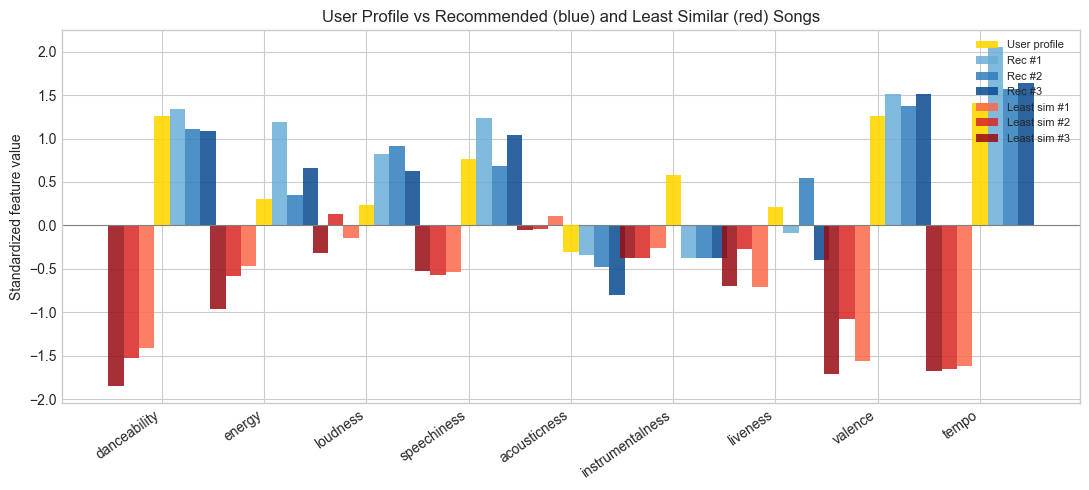

In [8]:
# Visualize: user profile vs top-3 recs vs bottom-3 (least similar)
top3_idx    = [ranked[i][0] for i in range(3)]
bottom3_idx = [ranked[-1-i][0] for i in range(3)]

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(AUDIO_COLS))
w = 0.15
colors_top    = cm.Blues(np.linspace(0.5, 0.9, 3))
colors_bottom = cm.Reds(np.linspace(0.5, 0.9, 3))

ax.bar(x, user_profile, width=w, label="User profile", color="gold", zorder=3, alpha=0.9)
for i, idx in enumerate(top3_idx):
    ax.bar(x + (i+1)*w, audio_features[idx], width=w, label=f"Rec #{i+1}", color=colors_top[i], alpha=0.85)
for i, idx in enumerate(bottom3_idx):
    ax.bar(x - (i+1)*w, audio_features[idx], width=w, label=f"Least sim #{i+1}", color=colors_bottom[i], alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(AUDIO_COLS, rotation=35, ha="right")
ax.set_ylabel("Standardized feature value")
ax.set_title("User Profile vs Recommended (blue) and Least Similar (red) Songs")
ax.legend(loc="upper right", fontsize=8)
ax.axhline(0, color="gray", linewidth=0.8)
plt.tight_layout()
plt.show()

> **Discussion:**
> - Recommended songs (blue) should closely match the user profile (gold bars).
> - Least similar songs (red) should diverge in at least one key dimension.
> - Which features drive the separation most? Does this match musical intuition?

---
## 9. Recommendation as a Machine Learning Problem

> *"A completely different approach to a recommendation system using item profiles and utility matrices*
> *is to treat the problem as one of machine learning. Regard the given data as a training set, and for*
> *each user, build a classifier that predicts the rating of all items. There are a great number of different*
> *classifiers, and it is not our purpose to teach this subject here. However, you should be aware of the*
> *option of developing a classifier for recommendation, for example, decision trees, a common classifier."*


In the ML framing:
- **Input (X):** item profile vectors (audio features, TF-IDF weights)
- **Output (y):** rating or binary like/dislike
- **Model:** logistic regression, decision tree, gradient boosting, …

**Compared to cosine similarity matching:**

| | Cosine Similarity | ML Classifier |
|---|---|---|
| **Data needed** | Item profiles only | Item profiles + user labels |
| **Personalization** | Average of liked items | Learned decision boundary |
| **Flexibility** | Fixed aggregation | Can learn non-linear preferences |
| **Interpretability** | High (feature similarity) | Depends on model |

For this course, we stay with the cosine approach — it's transparent and builds intuition.

---
## 10. Putting It All Together: Multi-Feature Recommendation

We combine one-hot (key+mode) + standardized audio into a single item vector,
then compare different feature spaces for the same user.

In [9]:
# Combined feature vector: [keymode (13-dim) | audio (9-dim)]
combined_features = np.hstack([keymode_features, audio_features])
print(f"Combined feature matrix: {combined_features.shape}  (13 key/mode + 9 audio = 22 dims)")

# Recompute user profile on combined features
combined_user_profile = combined_features[liked_indices].mean(axis=0)
sim_combined = cosine_similarity(combined_user_profile.reshape(1, -1), combined_features)[0]
ranked_combined = [(i, sim_combined[i]) for i in range(len(df)) if i not in liked_set]
ranked_combined.sort(key=lambda x: -x[1])

print()
print("Top-10 recs using combined features (key+mode + audio):")
print(f"  {'#':<4} {'Song':<40} {'Artist':<25} {'Cosine Sim':>10}")
print("  " + "-" * 85)
for rank, (idx, sim) in enumerate(ranked_combined[:10], 1):
    song   = df.loc[idx, COL_TRACK_NAME][:38]
    artist = df.loc[idx, COL_ARTIST][:23]
    print(f"  {rank:<4} {song:<40} {artist:<25} {sim:>10.4f}")

Combined feature matrix: (25000, 22)  (13 key/mode + 9 audio = 22 dims)

Top-10 recs using combined features (key+mode + audio):
  #    Song                                     Artist                    Cosine Sim
  -------------------------------------------------------------------------------------
  1    Puppy Dog Pals Main Title Theme          "Puppy Dog Pals" Cast         0.8677
  2    Blessed Be The Almighty                  Garnett Silk                  0.8385
  3    Chickenhead (feat. La Chat & Three 6 M   Project Pat, La Chat, T       0.8372
  4    Un Año Tarde                             Arcangel, Maluma              0.8304
  5    Ninguém Tá Puro                          Mc IG                         0.8125
  6    Que La Nota Le Suba                      J-King y Maximan              0.8104
  7    La fea                                   Grupo Marca Registrada        0.8091
  8    Amor Pa' Mi                              Sergent Garcia                0.8078
  9    Eu Não Te M

/Users/baotruong/manuscript-critique/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/baotruong/manuscript-critique/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/baotruong/manuscript-critique/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


---
## 11. Simulating Multiple Users: Different Tastes, Different Recommendations

Real recommendation systems serve millions of users with very different preferences.
Here we build three synthetic **user personas** by curating representative liked songs,
then show how each distinct taste profile leads to a different set of recommendations.

| User | Persona | Defining audio signal |
|---|---|---|
| **Alice** | Dance / EDM | High energy, high danceability, fast tempo |
| **Bob** | Acoustic / Folk | High acousticness, mellow energy, warm mood |
| **Carlos** | Hip-Hop / Rap | High speechiness, danceable, moderate energy |

Each user profile is built the same way as Section 7: average the audio vectors of liked songs.

In [10]:
PERSONAS = {
    "Alice (Dance/EDM)": {
        "filter": lambda d: (d["energy"] > 0.80) & (d["danceability"] > 0.70) & (d["tempo"] > 120),
        "color":  "#E63946",
        "n":      5,
    },
    "Bob (Acoustic/Folk)": {
        "filter": lambda d: (d["acousticness"] > 0.70) & (d["energy"] < 0.40) & (d["valence"] > 0.40),
        "color":  "#2A9D8F",
        "n":      5,
    },
    "Carlos (Hip-Hop)": {
        "filter": lambda d: (d["speechiness"] > 0.15) & (d["danceability"] > 0.65) & (d["energy"].between(0.4, 0.8)),
        "color":  "#F4A261",
        "n":      5,
    },
}

user_profiles_multi = {}   # persona → mean standardized audio vector
user_liked_multi    = {}   # persona → list of liked song indices

for persona, cfg in PERSONAS.items():
    pool     = df[cfg["filter"](df)]
    liked    = pool.sample(min(cfg["n"], len(pool)), random_state=RANDOM_STATE)
    idx_list = liked.index.tolist()

    user_profiles_multi[persona] = audio_features[idx_list].mean(axis=0)
    user_liked_multi[persona]    = idx_list

    print(f"{persona}  →  {len(idx_list)} liked songs")
    for _, row in liked.iterrows():
        print(f"    • {row[COL_TRACK_NAME]} by {row[COL_ARTIST]}"
              f"  [energy={row['energy']:.2f}, dance={row['danceability']:.2f}, speech={row['speechiness']:.2f}]")
    print()

Alice (Dance/EDM)  →  5 liked songs
    • Turn Me On - Extended by David Guetta  [energy=0.89, dance=0.79, speech=0.08]
    • Destiny (Classic Vocal Mixture) by Martin Solveig  [energy=0.86, dance=0.89, speech=0.07]
    • Pata de Perro by Maldita Vecindad Y Los Hijos Del 5to. Patio  [energy=0.88, dance=0.70, speech=0.05]
    • LIKEY - Japanese ver. by TWICE  [energy=0.89, dance=0.72, speech=0.04]
    • Hoch auf dem gelben Wagen - Remastered 2016 by Mickie Krause  [energy=0.97, dance=0.71, speech=0.03]

Bob (Acoustic/Folk)  →  5 liked songs
    • Tightrope by Matt Alber  [energy=0.25, dance=0.72, speech=0.03]
    • Please Keep Loving Me - Acoustic by James TW  [energy=0.18, dance=0.49, speech=0.05]
    • ¿Y Tú Qué Has Hecho? by Buena Vista Social Club  [energy=0.27, dance=0.55, speech=0.04]
    • Crocodile Roll by John Williamson  [energy=0.24, dance=0.86, speech=0.23]
    • Sweet Thing by Rufus, Chaka Khan  [energy=0.39, dance=0.71, speech=0.05]

Carlos (Hip-Hop)  →  5 liked songs
    

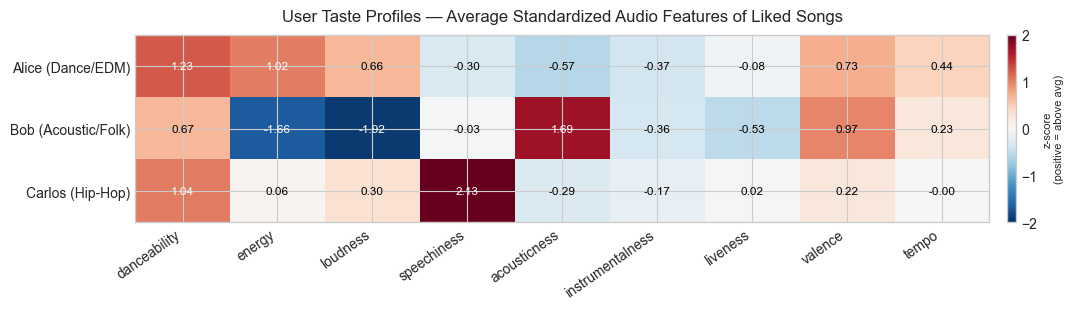

In [11]:
# Heatmap: rows = users, columns = audio features
# Cell value = average z-score of liked songs on that feature
persona_names  = list(PERSONAS.keys())
profile_matrix = np.stack([user_profiles_multi[p] for p in persona_names])  # (3, 9)

fig, ax = plt.subplots(figsize=(11, 3.2))
im = ax.imshow(profile_matrix, cmap="RdBu_r", aspect="auto", vmin=-2.0, vmax=2.0)

ax.set_xticks(range(len(AUDIO_COLS)))
ax.set_xticklabels(AUDIO_COLS, rotation=35, ha="right", fontsize=10)
ax.set_yticks(range(len(persona_names)))
ax.set_yticklabels(persona_names, fontsize=10)
ax.set_title("User Taste Profiles — Average Standardized Audio Features of Liked Songs",
             fontsize=12, pad=10)

cbar = plt.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
cbar.set_label("z-score\n(positive = above avg)", fontsize=8)

for i in range(len(persona_names)):
    for j in range(len(AUDIO_COLS)):
        val        = profile_matrix[i, j]
        text_color = "white" if abs(val) > 1.0 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                fontsize=8.5, color=text_color)

plt.tight_layout()
plt.show()

In [12]:
import warnings

N_RECS       = 5
persona_recs = {}   # store for later use

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for persona, profile in user_profiles_multi.items():
        liked_set_p = set(user_liked_multi[persona])
        sims_p      = cosine_similarity(profile.reshape(1, -1), audio_features)[0]
        ranked_p    = sorted(
            [(i, sims_p[i]) for i in range(len(df)) if i not in liked_set_p],
            key=lambda x: -x[1],
        )
        persona_recs[persona] = ranked_p

        print(f"\n{'─'*72}")
        print(f"  Top-{N_RECS} recommendations for  {persona}")
        print(f"{'─'*72}")
        print(f"  {'#':<4} {'Song':<36} {'Artist':<24} {'Cosine Sim':>10}")
        print(f"  {'─'*74}")
        for rank, (idx, sim) in enumerate(ranked_p[:N_RECS], 1):
            song   = df.loc[idx, COL_TRACK_NAME][:34]
            artist = df.loc[idx, COL_ARTIST][:22]
            print(f"  {rank:<4} {song:<36} {artist:<24} {sim:>10.4f}")


────────────────────────────────────────────────────────────────────────
  Top-5 recommendations for  Alice (Dance/EDM)
────────────────────────────────────────────────────────────────────────
  #    Song                                 Artist                   Cosine Sim
  ──────────────────────────────────────────────────────────────────────────
  1    Round of Applause                    Lecrae                       0.9758
  2    Get Up (Rattle)                      Bingo Players, Far Eas       0.9615
  3    Me & My Man                          Chromeo                      0.9592
  4    I'm Not A Saint                      Billy Raffoul                0.9542
  5    Techno Disco Tool - Radio Edit       Mella Dee                    0.9529

────────────────────────────────────────────────────────────────────────
  Top-5 recommendations for  Bob (Acoustic/Folk)
────────────────────────────────────────────────────────────────────────
  #    Song                                 Artist   

/Users/baotruong/manuscript-critique/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/baotruong/manuscript-critique/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/baotruong/manuscript-critique/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T
/var/folders/7d/0547_k810ns16ml7sb03wvgh0000gn/T/ipykernel_4212/245106098.py:54: UserWarning: Glyph 9670 (\N{BLACK DIAMOND}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/7d/0547_k810ns16ml7sb03wvgh0000gn/T/ipykernel_4212/245106098.py:54: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
/Users/baotruong/manuscript-critique/.venv/lib/python3.9/si

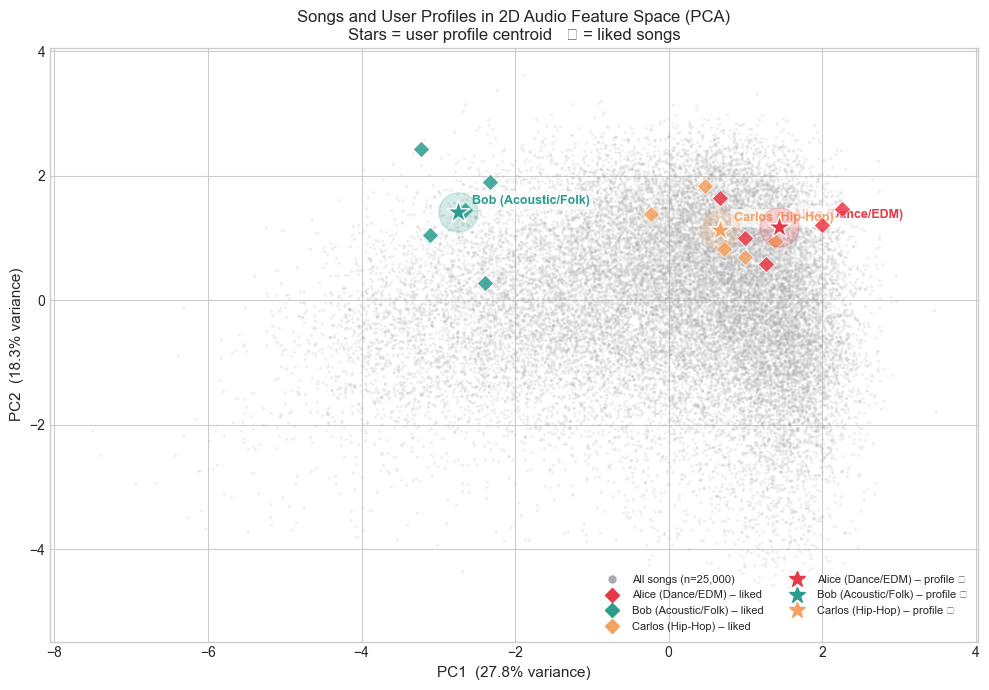

In [13]:
from sklearn.decomposition import PCA
import matplotlib.lines as mlines

pca      = PCA(n_components=2, random_state=RANDOM_STATE)
songs_2d = pca.fit_transform(audio_features)        # (N, 2)

users_2d = {
    persona: pca.transform(profile.reshape(1, -1))[0]
    for persona, profile in user_profiles_multi.items()
}

fig, ax = plt.subplots(figsize=(10, 7))

# All songs: light gray background
ax.scatter(songs_2d[:, 0], songs_2d[:, 1], s=2, alpha=0.12, color="#AAAAAA",
           rasterized=True)

# Liked songs per user: colored diamonds
for persona, liked_idx in user_liked_multi.items():
    color = PERSONAS[persona]["color"]
    ax.scatter(songs_2d[liked_idx, 0], songs_2d[liked_idx, 1],
               s=70, color=color, marker="D", alpha=0.85,
               edgecolors="white", linewidth=0.6, zorder=4)

# User profile centroids: large stars
for persona, (x, y) in users_2d.items():
    color = PERSONAS[persona]["color"]
    ax.scatter(x, y, s=800, color=color, alpha=0.20, zorder=5)   # soft halo
    ax.scatter(x, y, s=300, color=color, marker="*", zorder=6,
               edgecolors="white", linewidth=1.0)
    ax.annotate(persona, (x, y), textcoords="offset points", xytext=(10, 6),
                fontsize=9, color=color, fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.25", fc="white", alpha=0.75, ec="none"))

ax.set_xlabel(f"PC1  ({pca.explained_variance_ratio_[0]*100:.1f}% variance)", fontsize=11)
ax.set_ylabel(f"PC2  ({pca.explained_variance_ratio_[1]*100:.1f}% variance)", fontsize=11)
ax.set_title(
    "Songs and User Profiles in 2D Audio Feature Space (PCA)\n"
    "Stars = user profile centroid   ◆ = liked songs",
    fontsize=12,
)

legend_elems = [
    mlines.Line2D([0], [0], color="#AAAAAA", marker="o", markersize=5,
                  linewidth=0, label="All songs (n=25,000)"),
    *[mlines.Line2D([0], [0], color=PERSONAS[p]["color"], marker="D",
                    markersize=7, linewidth=0, label=f"{p} – liked")
      for p in PERSONAS],
    *[mlines.Line2D([0], [0], color=PERSONAS[p]["color"], marker="*",
                    markersize=12, linewidth=0, label=f"{p} – profile ★")
      for p in PERSONAS],
]
ax.legend(handles=legend_elems, loc="lower right", fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

> **What to notice:**
> - Each user's profile star ★ sits in a different region of audio feature space — their centroids are well-separated.
> - Liked songs (diamonds) cluster around their user's star, confirming the profile vector is a good centroid of taste.
> - Because the profiles are far apart, Alice, Bob, and Carlos receive largely non-overlapping recommendations.
> - If two users occupy similar positions, they'd see similar recommendations — the content-based analog of collaborative overlap.

---
## Summary

| Concept | Key idea | Dataset example |
|---|---|---|
| Item profile | Record of feature-value pairs for each item | Audio features + lyrics per song |
| Feature types | Categorical → one-hot; numerical → standardize | Key/mode vs tempo/energy |
| User profile | Aggregate item profiles of liked songs | Average audio vector of 3 liked songs |
| Recommendation | Rank items by cosine similarity to user profile | Top-10 audio-similar songs |
| ML framing | Predict rating from item features | Logistic regression on audio vectors |

**Next:** Module 3 visualizes these high-dimensional profiles in 2D to reveal hidden structure.